In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def check_distribution_and_nulls(df):
    # Check for null values
    print("Null Values in Each Column:")
    print(df.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df.isnull().mean() * 100).round(2))

    # # Plot distribution for each column
    # for column in df.columns:
    #     plt.figure(figsize=(8, 4))
    #     if pd.api.types.is_numeric_dtype(df[column]):
    #         sns.histplot(df[column].dropna(), kde=True, bins=30)
    #     else:
    #         df[column].value_counts(dropna=False).plot(kind='bar')
    #     plt.title(f'Distribution of "{column}"')
    #     plt.xlabel(column)
    #     plt.ylabel("Count")
    #     plt.tight_layout()
    #     plt.show()


In [5]:
df = pd.read_csv("report\provider\RAW4.18_COVIDProviderInfo_All.csv", encoding='ISO-8859-1')
check_distribution_and_nulls(df)

Null Values in Each Column:
Federal Provider Number                                        0
Year                                                           0
Provider Name                                                  0
Provider City                                                  0
Provider State                                                 0
Ownership Type                                                 0
Number of Certified Beds                                       0
Average Number of Residents per Day                          135
Provider Type                                                  0
Overall Rating                                               440
Health Inspection Rating                                     440
QM Rating                                                    500
Long-Stay QM Rating                                         1277
Short-Stay QM Rating                                        4545
Staffing Rating                                             17

In [ ]:
def remove_nulls_from_columns(df, column_list):
    cleaned_df = df.dropna(subset=column_list).copy()
    return cleaned_df

# Remove rows where columns are null
columns_to_check = ['Short-Stay QM Rating', 'quality_rating', 'staffing_rating', 'RN_staffing_rating']
df_cleaned = remove_nulls_from_columns(df, columns_to_check)

print(f"Original rows: {len(df)}, Cleaned rows: {len(df_cleaned)}")

Original rows: 78025, Cleaned rows: 30175


In [16]:
def check_distribution_and_nulls(df_cleaned):
    # Check for null values
    print("Null Values in Each Column:")
    print(df_cleaned.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df_cleaned.isnull().mean() * 100).round(2))

    # Plot distribution for each column
    # for column in df.columns:
    #     plt.figure(figsize=(8, 4))
    #     if pd.api.types.is_numeric_dtype(df[column]):
    #         sns.histplot(df_cleaned[column].dropna(), kde=True, bins=30)
    #     else:
    #         df_cleaned[column].value_counts(dropna=False).plot(kind='bar')
    #     plt.title(f'Distribution of "{column}"')
    #     plt.xlabel(column)
    #     plt.ylabel("Count")
    #     plt.tight_layout()
    #     plt.show()

check_distribution_and_nulls(df_cleaned)

Null Values in Each Column:
provnum                          0
PROVNAME                         0
Year                             0
CITY                             0
STATE                            0
OWNERSHIP                        0
BEDCERT                          0
RESTOT                          94
CERTIFICATION                    0
overall_rating                   0
survey_rating                    0
quality_rating                   0
staffing_rating                  0
RN_staffing_rating               0
adj_total                      884
WEIGHTED_ALL_CYCLES_SCORE        0
incident_cnt                     0
cmplnt_cnt                       0
Unnamed: 18                  15410
Unnamed: 19                  15672
Unnamed: 20                  15672
Unnamed: 21                  15672
Unnamed: 22                  15672
Unnamed: 23                  15672
dtype: int64

Percentage of Nulls:
provnum                       0.00
PROVNAME                      0.00
Year                       

In [17]:
def remove_outliers_iqr(df_cleaned):
    numeric_cols = df_cleaned.select_dtypes(include='number').columns
    clean_df = df_cleaned.copy()

    for col in numeric_cols:
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Keep only rows within bounds
        clean_df = clean_df[(clean_df[col] >= lower_bound) & (clean_df[col] <= upper_bound)]

    return clean_df

df_no_outliers = remove_outliers_iqr(df_cleaned)

print(f"Original rows: {len(df)}, After IQR filtering: {len(df_no_outliers)}")

Original rows: 78025, After IQR filtering: 8693


Null Values in Each Column:
provnum                      0
PROVNAME                     0
Year                         0
CITY                         0
STATE                        0
OWNERSHIP                    0
BEDCERT                      0
RESTOT                       0
CERTIFICATION                0
overall_rating               0
survey_rating                0
quality_rating               0
staffing_rating              0
RN_staffing_rating           0
adj_total                    0
WEIGHTED_ALL_CYCLES_SCORE    0
incident_cnt                 0
cmplnt_cnt                   0
Unnamed: 18                  0
Unnamed: 19                  0
Unnamed: 20                  0
Unnamed: 21                  0
Unnamed: 22                  0
Unnamed: 23                  0
dtype: int64

Percentage of Nulls:
provnum                      0.0
PROVNAME                     0.0
Year                         0.0
CITY                         0.0
STATE                        0.0
OWNERSHIP                   

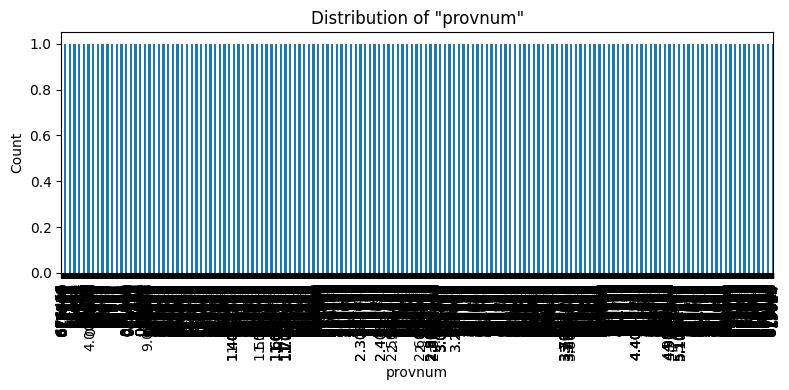

C:\Users\Julian Amberg\AppData\Local\Temp\ipykernel_2820\3780020293.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


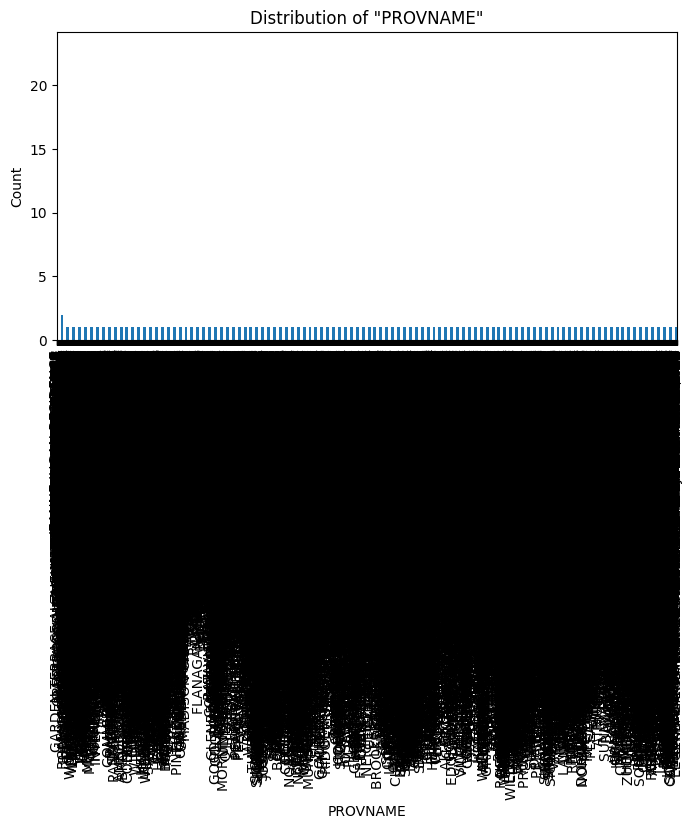

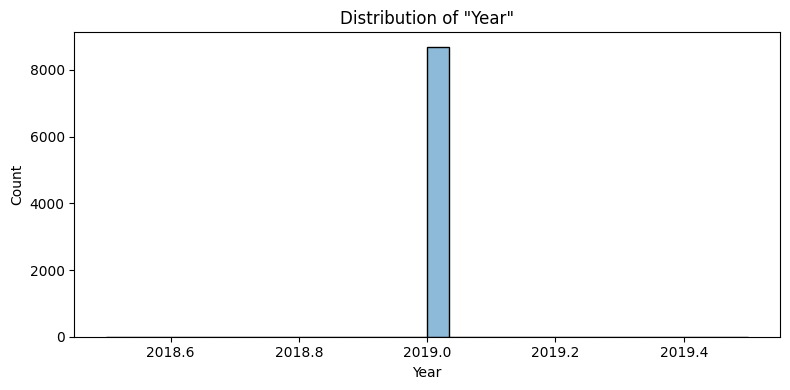

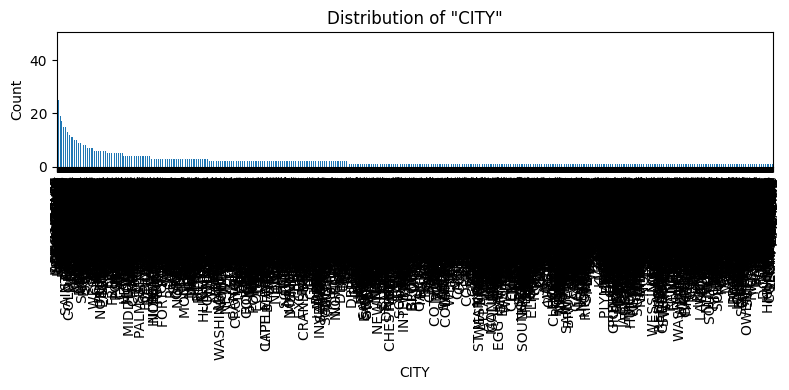

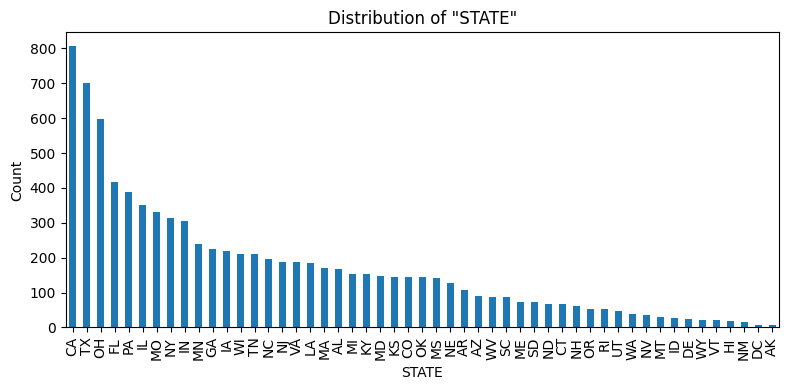

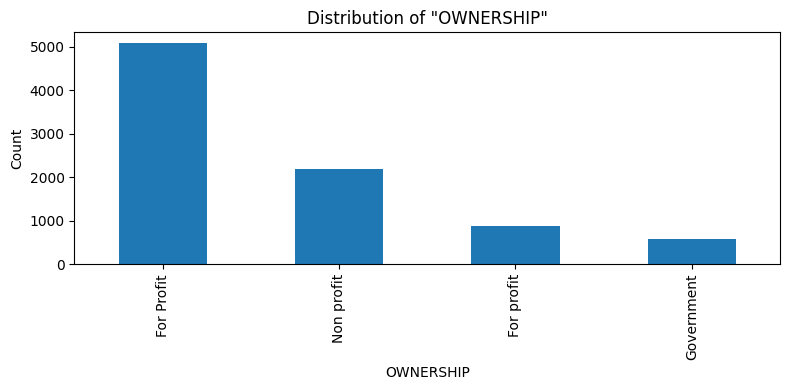

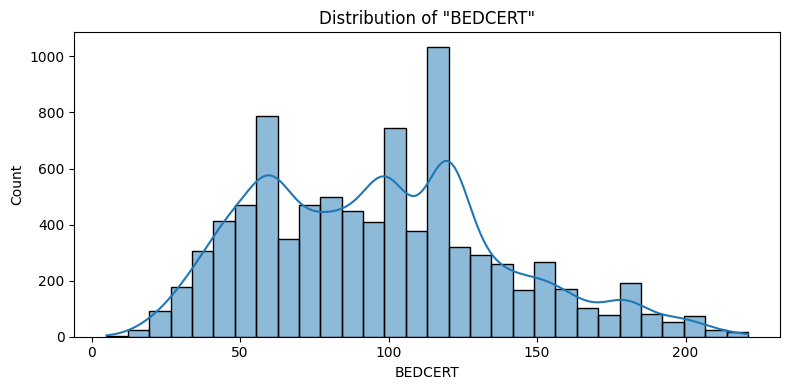

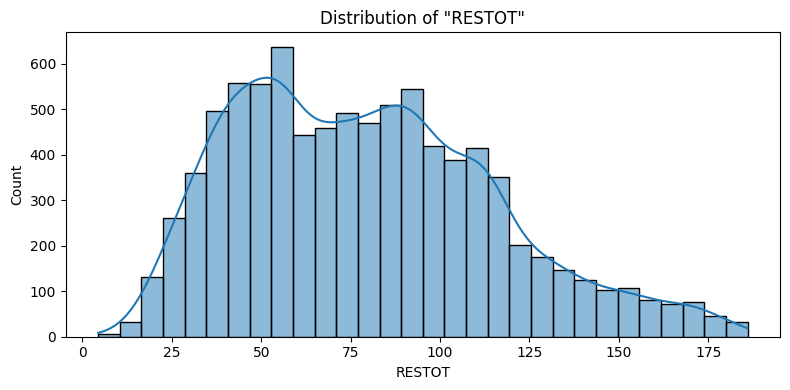

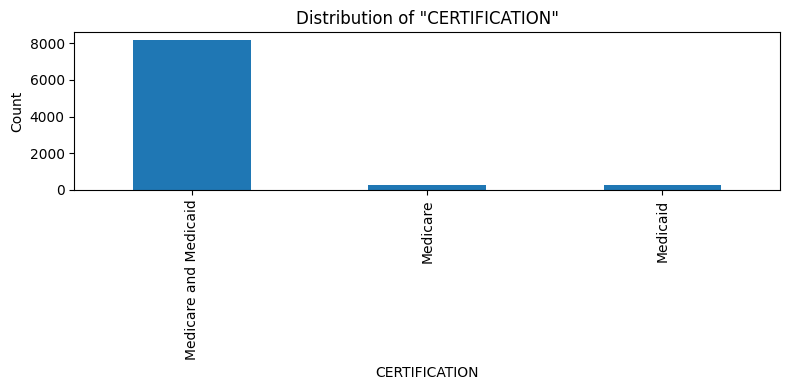

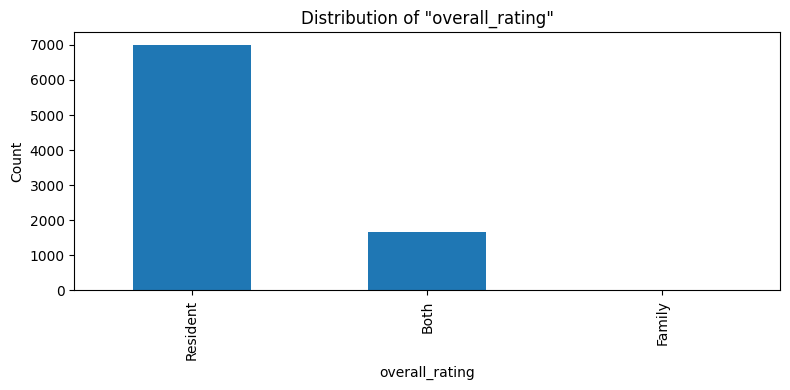

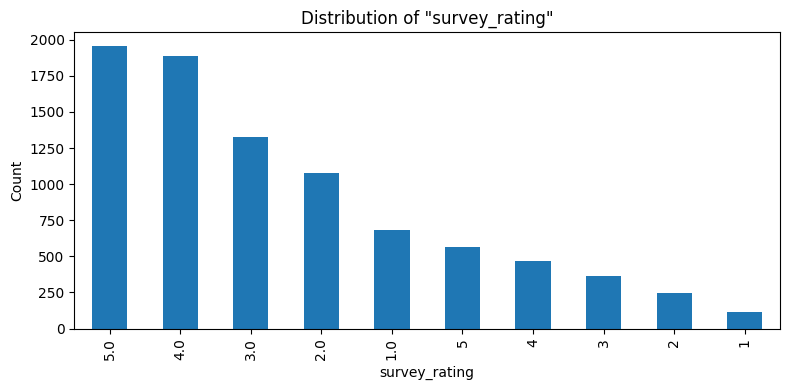

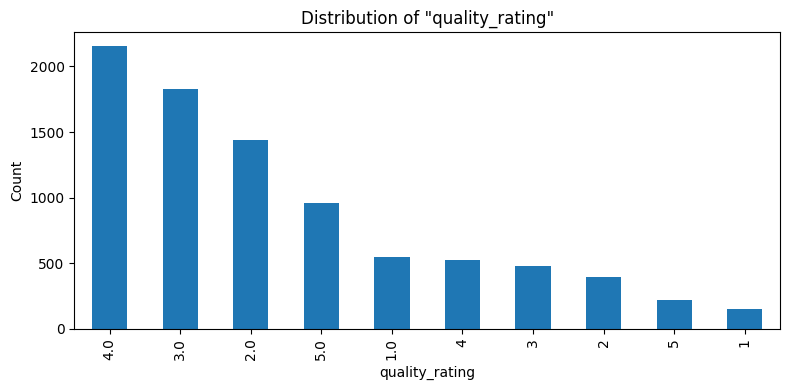

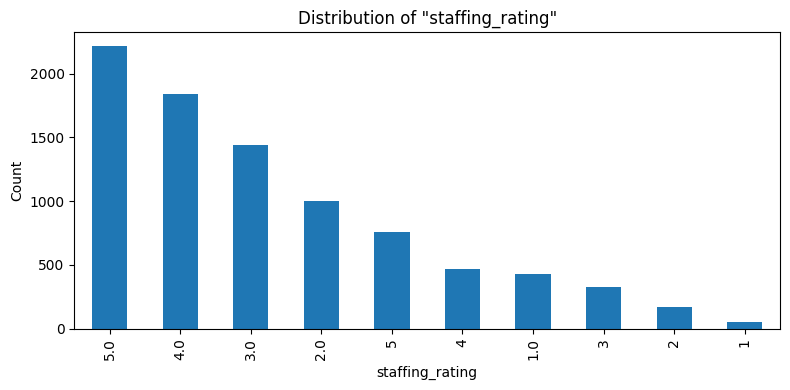

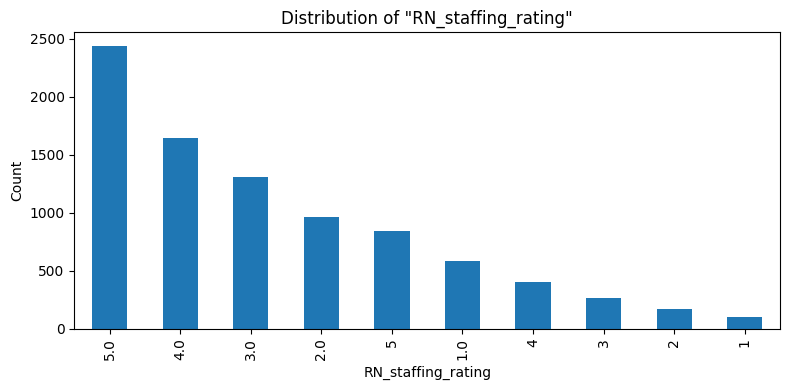

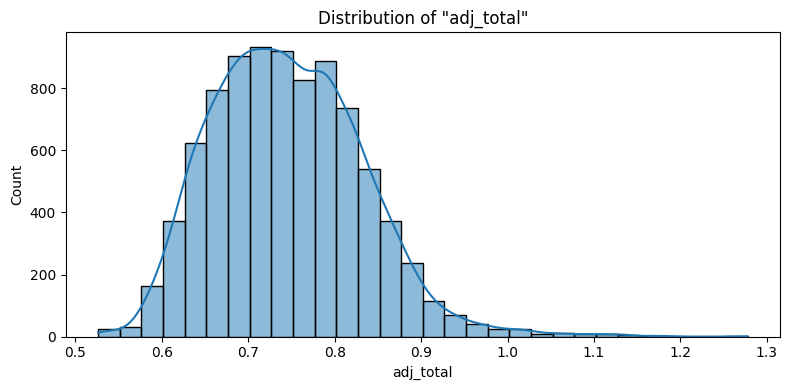

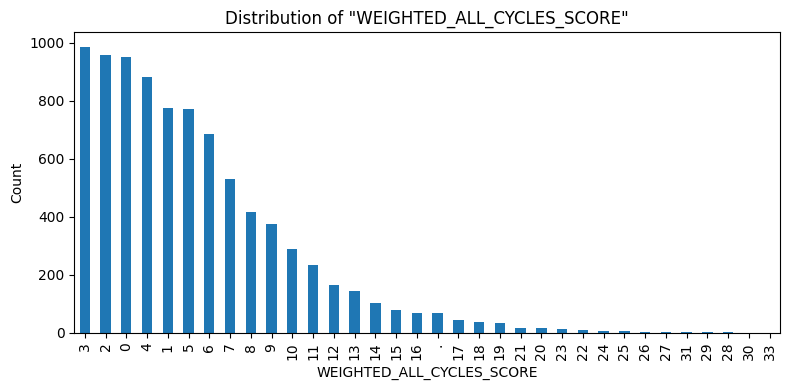

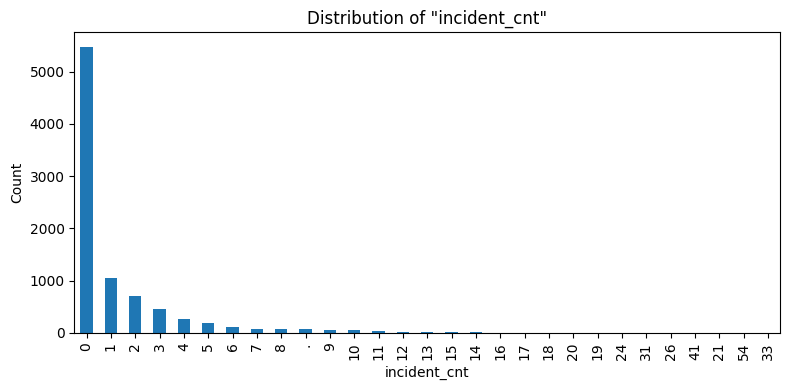

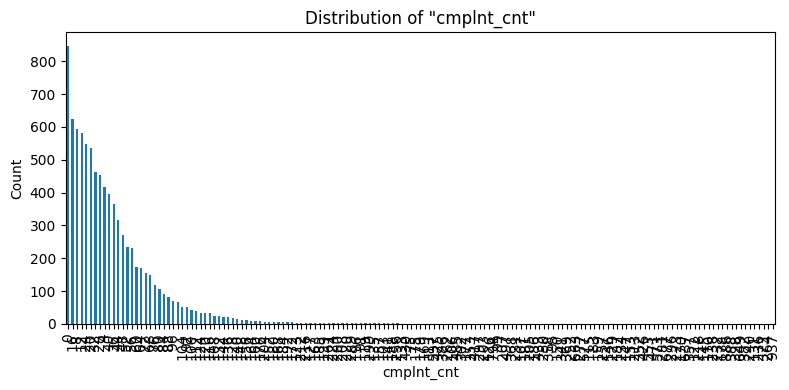

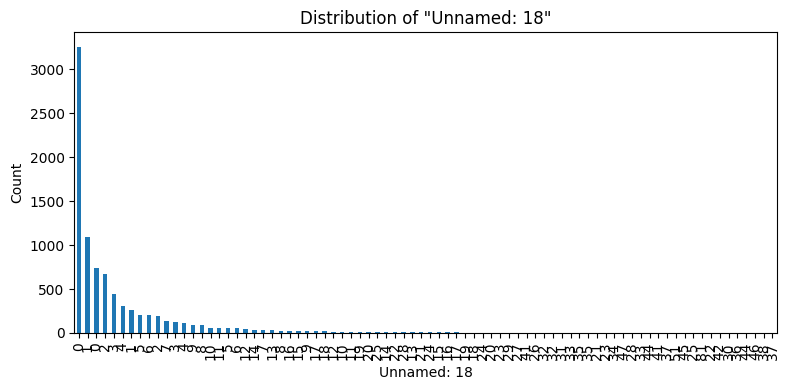

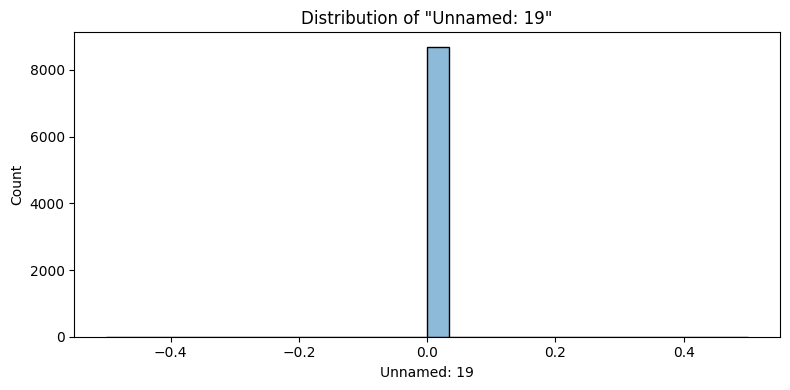

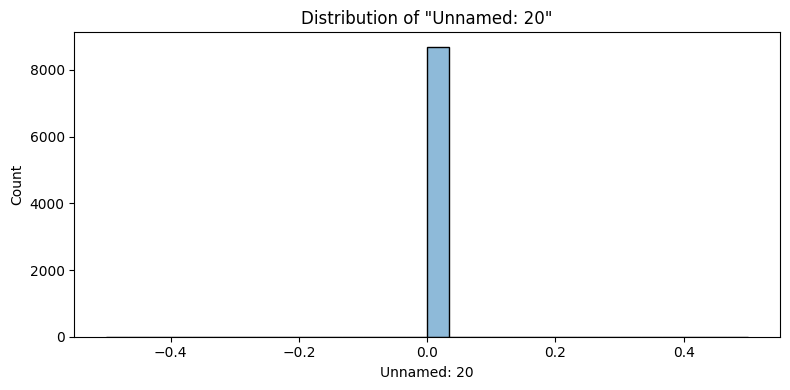

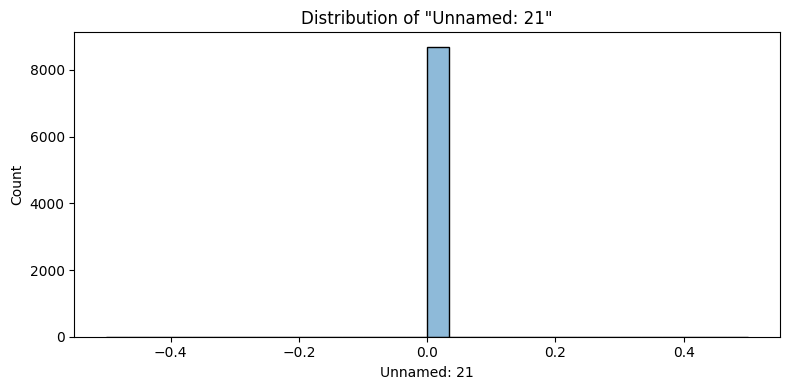

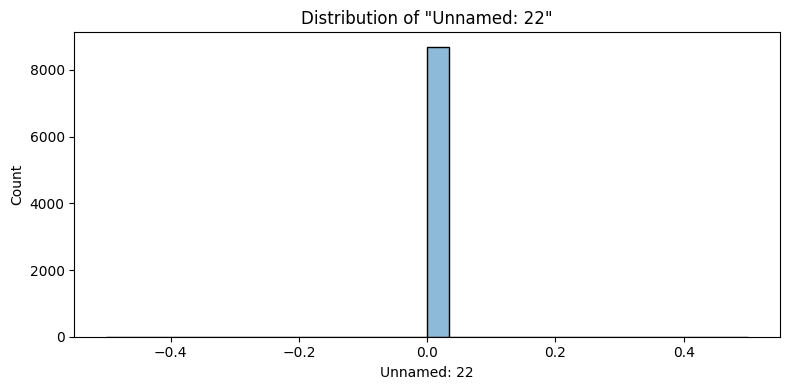

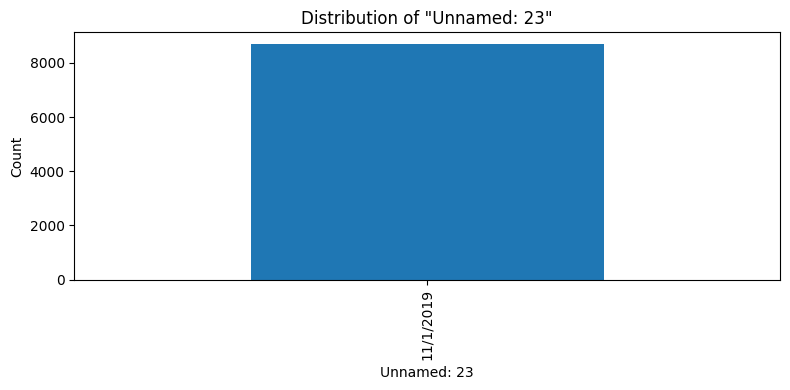

In [18]:
def check_distribution_and_nulls(df_no_outliers):
    # Check for null values
    print("Null Values in Each Column:")
    print(df_no_outliers.isnull().sum())
    print("\nPercentage of Nulls:")
    print((df_no_outliers.isnull().mean() * 100).round(2))

    # Plot distribution for each column
    for column in df_no_outliers.columns:
        plt.figure(figsize=(8, 4))
        if pd.api.types.is_numeric_dtype(df_no_outliers[column]):
            sns.histplot(df_no_outliers[column].dropna(), kde=True, bins=30)
        else:
            df_no_outliers[column].value_counts(dropna=False).plot(kind='bar')
        plt.title(f'Distribution of "{column}"')
        plt.xlabel(column)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

check_distribution_and_nulls(df_no_outliers)